# Hierarchical integration analysis notebook

The analysis in this notebook uses the PathIntegrate package to perform hierarchical integration. It is important to note that only pseudobulked scRNA and O-link data is used in this analysis (because of the matching feature IDs with databases), whereas the other integration analyses consider the miRNA and LCMS data as well.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathintegrate
import sspa
import mygene
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
np.random.seed(89)

In [2]:
project_root = Path.cwd().parent
print(project_root)

c:\Users\joddy\repos\multiomics_integration_publication


## Data processing

Pre-processed scRNA and O-link data are imported here. Only the most variable ~ 3000 features from the scRNA are imported here. Pathway data is read locally due to some issues reading gmt files as part of the PathIntegrate package.

In [3]:
# import pre-processed data
lcms_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'lcms.feather')
miRNA_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'miRNA.feather')
olink_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'olink.feather')
scRNA_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'scRNA.feather')
combined_metadata = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'combined_metadata.feather')
nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_proportions_run_4.csv')

In [4]:
# convert miRNA ENS... symbols to gene symbols for pathintegrate using mygene, the structure of the miRNA data is one column called "label" with sample name. the remaininc olumns are all miRAN IDs.
mg = mygene.MyGeneInfo()
# extract all non label column names
mirna_ens_ids = miRNA_data.columns[1:]
# try adding corresponding gene symbols to the miRNA data frame
mirna_symbols = mg.querymany(mirna_ens_ids, scopes='ensembl.gene', fields='symbol', species='human')
mirna_symbol_dict = {item['query']: item.get('symbol', '') for item in mirna_symbols}
miRNA_data.rename(columns=mirna_symbol_dict, inplace=True)

In [5]:
# Extract vessel and day numbers
nk_cell_proportions[['vessel', 'day']] = nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
nk_cell_proportions['vessel'] = pd.to_numeric(nk_cell_proportions['vessel'])
nk_cell_proportions['day'] = pd.to_numeric(nk_cell_proportions['day'])
nk_cell_proportions['label'] = 'r4_v' + nk_cell_proportions['vessel'].astype(str) + '_d' + nk_cell_proportions['day'].astype(str)
subset_nk = nk_cell_proportions[nk_cell_proportions['label'].isin(combined_metadata['label'])]

In [6]:
conditions = [
    (subset_nk['day'] >= 1) & (subset_nk['day'] <= 3),
    (subset_nk['day'] >= 4) & (subset_nk['day'] <= 6),
    (subset_nk['day'] >= 8) & (subset_nk['day'] <= 12),
    (subset_nk['day'] >= 13) & (subset_nk['day'] <= 15),
    (subset_nk['day'] >= 19) & (subset_nk['day'] <= 26),
    (subset_nk['day'] >= 29) & (subset_nk['day'] <= 36)
]

# Define the corresponding values for each condition
values = [
    'mesoderm_commitment',
    'hemogenic_endothelium',
    'early_haem',
    'late_haem',
    'early_NK',
    'late_NK'
]

# Use np.select to assign values based on conditions
subset_nk['stage'] = np.select(conditions, values, default='undefined')

<positron-console-cell-6>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [7]:
def gmt_to_wide_df(filepath):
    """
    Reads a GMT file and returns a DataFrame with each pathway as a row and each member in its own column.
    """
    rows = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway_id = parts[0]
            pathway_name = parts[1]
            members = parts[2:]
            row = [pathway_id, pathway_name] + members
            rows.append(row)
    # Find the maximum number of members
    max_members = max(len(row) for row in rows)
    # Pad rows so all have the same length
    for row in rows:
        row += [None] * (max_members - len(row))
    columns = ['Pathway_id', 'Pathway_name'] + [f'Member_{i+1}' for i in range(max_members-2)]
    return pd.DataFrame(rows, columns=columns)

# Usage:
local_gmt_path = project_root / "00_data" / "Reactome_Homo_sapiens_pathways_multiomics_R92.gmt"
mo_paths = gmt_to_wide_df(local_gmt_path)

In [8]:
# search mo_paths for any IDs across the whole dataset matching "MIR". The MIR in mo_paths could be in any column beginning with "Member"
mirna_ids = []
for col in mo_paths.columns:
    if col.startswith("Member"):
        mirna_ids.extend(mo_paths[col][mo_paths[col].str.contains("MIR", na=False)].tolist())

In [9]:
# find all strings matching "MIR" (at least in part) in mo_paths

# Create a list to store MIR entries with their locations
mir_records = []

for col in mo_paths.columns:
    if col.startswith("Member"):
        # Find rows where the column contains "MIR"
        mask = mo_paths[col].str.contains("MIR", na=False)
        for row_idx in mo_paths[mask].index:
            mir_records.append({
                "MIR_ID": mo_paths.loc[row_idx, col],
                "Column": col,
                "Row": row_idx
            })

# Create DataFrame from records
mirna_df = pd.DataFrame(mir_records)

In [10]:
# add a column to mirna_df stating if the miRNA ID is present in the miRNA_data columns (i.e., if we have data for that miRNA)
mirna_df['In_miRNA_data'] = mirna_df['MIR_ID'].isin(miRNA_data.columns)

In [11]:
miRNA_data.index = miRNA_data['label']
miRNA_data = miRNA_data.drop(columns=['label'])

olink_data.index = olink_data['label']
olink_data = olink_data.drop(columns=['label'])

subset_nk = subset_nk.set_index('label').sort_index()

# Sort miRNA data and olink_data by their index in alphanumeric order
miRNA_data = miRNA_data.sort_index()
olink_data = olink_data.sort_index()

# Set subset_nk index to 'label' and sort in alphanumeric order
subset_nk = subset_nk.sort_index()

# check that the indexes match up
print(olink_data.index.equals(subset_nk.index))
print(miRNA_data.index.equals(subset_nk.index))

True
True


## Model performance assessment

Nested cross-validation is used here to assess model performance. Five-fold cross-validation with ten repeats was used for the outer folds, and three-fold cross-validation within the inner folds for hyperparameter tuning.

Two hyperparameters were selected for tuning: model_max_features and model_min_samples_leaf. The model_max_features parameter controls the number of features to consider when looking for the best split, while the model_min_samples_leaf parameter sets the minimum number of samples required to be at a leaf node.

Median R2 and RMSE values were reasonable, but the distribution of values was quite broad for both - likely due to the small sample size.

In [14]:
def ntile(series, n):
    # Assign ranks, then integer-divide into n bins
    return ((series.rank(method='first') - 1) // (len(series) / n)).astype(int)

# Example usage:
stratify_bins = ntile(subset_nk['proportion_NK'], 4).astype(str)

In [19]:
n_splits = 5
n_repeats = 5
random_state = 42
param_grid = {
    "model__max_features": [1, 8, 15], 
    "model__min_samples_leaf": [2, 11, 20]
}

# Store results
all_rmse = []
all_r2 = []

model_counter = 0

for repeat in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state + repeat)
    for train_idx, test_idx in skf.split(subset_nk, stratify_bins):
        model_counter += 1
        print(f"Model #{model_counter}")
        train_idx = subset_nk.index[train_idx]
        test_idx = subset_nk.index[test_idx]
        
        olink_train = olink_data.loc[train_idx]
        olink_test = olink_data.loc[test_idx]
        miRNA_train = miRNA_data.loc[train_idx]
        miRNA_test = miRNA_data.loc[test_idx]
        y_train = subset_nk.loc[train_idx, 'proportion_NK']
        y_test = subset_nk.loc[test_idx, 'proportion_NK']
        
        # Fit PathIntegrate model
        pi_model = pathintegrate.PathIntegrate(
            omics_data={'Proteomics_train': olink_train, 'miRNA_train': miRNA_train},
            metadata=y_train,
            pathway_source=mo_paths,
            sspa_scoring=sspa.sspa_SVD,
            min_coverage=2
        )

        # Bin the training target for stratification
        stratify_bins_train = ntile(y_train, 4).astype(str)
        inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        # Perform grid search for hyperparameter tuning
        sv_grid_search = pi_model.SingleViewGridSearchCV(
            model=RandomForestRegressor,
            param_grid=param_grid,
            grid_search_params={
                'cv': inner_skf.split(y_train, stratify_bins_train),
                'scoring': 'neg_root_mean_squared_error',
                'verbose': 2,
                'n_jobs': -1
            }
        )

        # fit model with optimal hyperparameters
        sv_model = pi_model.SingleView(
            model=RandomForestRegressor,
            model_params={'max_features': sv_grid_search.best_params_['model__max_features'],
                          'min_samples_leaf': sv_grid_search.best_params_['model__min_samples_leaf'],
                          'n_jobs': -1
                          }
        )
        
        # Prepare test data
        concat_test = pd.concat([olink_test, miRNA_test], axis=1)
        pipe_sv = Pipeline([
            ('Scaler', StandardScaler().set_output(transform="pandas")),
            ('sspa', pi_model.sspa_method(pi_model.pathway_source, pi_model.min_coverage)),
        ])
        test_set_scores = pipe_sv.fit_transform(concat_test)
        sv_pred = sv_model.predict(test_set_scores)
        
        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_test, sv_pred))
        r2 = r2_score(y_test, sv_pred)
        all_rmse.append(rmse)
        all_r2.append(r2)

print(f"Mean RMSE: {np.mean(all_rmse):.3f} ± {np.std(all_rmse):.3f}")
print(f"Mean R2: {np.mean(all_r2):.3f} ± {np.std(all_r2):.3f}")

Model #1
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #2
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #3
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #4
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #5
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #6
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #7
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #8
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #9
Fitting

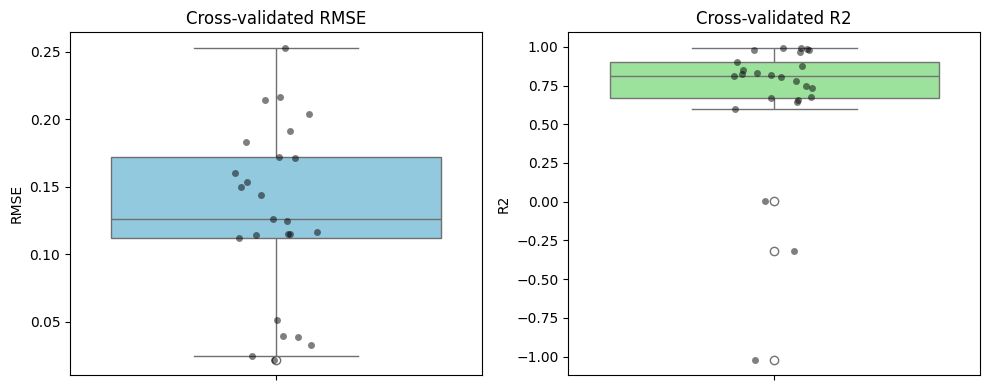

In [21]:
# cv_results_df = pd.read_feather(project_root / '00_data' / 'cross_validated_sv_metrics.feather')

# put all r2 and rmse values into a dataframe for plotting
cv_results_df = pd.DataFrame({
    'RMSE': all_rmse,
    'R2': all_r2
})

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y='RMSE', data=cv_results_df, color='skyblue')
sns.stripplot(y='RMSE', data=cv_results_df, color='k', alpha=0.5, jitter=True)
plt.title('Cross-validated RMSE')
plt.ylabel('RMSE')

plt.subplot(1, 2, 2)
sns.boxplot(y='R2', data=cv_results_df, color='lightgreen')
sns.stripplot(y='R2', data=cv_results_df, color='k', alpha=0.5, jitter=True)
plt.title('Cross-validated R2')
plt.ylabel('R2')

plt.tight_layout()
plt.show()

In [23]:
# write summary metrics to feather. Mean, median, and standard deviation for RMSE and R2
summary_metrics = {
    'Metric': ['RMSE', 'R2'],
    'Mean': [np.mean(all_rmse), np.mean(all_r2)],
    'Median': [np.median(all_rmse), np.median(all_r2)],
    'Std': [np.std(all_rmse), np.std(all_r2)]
}

summary_metrics_df = pd.DataFrame(summary_metrics)
summary_metrics_df.to_feather(project_root / '00_data' / 'hierarchical_summary_metrics_scRNA_removed.feather')

## Feature importances

To look at feature importances, hyperparameter tuning is performed with five-fold cross-validation and a final model is then fit on the full dataset. Feature importances are then extracted from this model. Note that the top features/pathways change when setting different seeds, indicating that the results are not very robust. This is likely due to the small sample size.

The features presented below are different from the ones presented in the paper, likely due to the reasons mentioned above.

Feature importances here are calculated as the mean decrease in impurity (MDI) importance, which is a measure of how much each feature contributes to reducing uncertainty in the model's predictions.

In [24]:
# instantiate a model with all the data
all_data_pi_model = pathintegrate.PathIntegrate(
    omics_data={'Proteomics_data': olink_data, 'miRNA_data': miRNA_data},
    metadata=subset_nk['proportion_NK'],
    pathway_source=mo_paths,
    sspa_scoring=sspa.sspa_SVD,
    min_coverage=2)

In [15]:
all_data_param_grid = {
    "model__max_features": [1, 8, 15], 
    "model__min_samples_leaf": [2, 11, 20]
}
# Create stratified splitter
all_data_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratify_bins = ntile(subset_nk['proportion_NK'], 4).astype(str)

all_data_sv_grid_search = all_data_pi_model.SingleViewGridSearchCV(
    model=RandomForestRegressor,
    param_grid=all_data_param_grid,
    grid_search_params={
        'cv': all_data_skf.split(subset_nk, stratify_bins),
        'scoring': 'neg_root_mean_squared_error',
        'verbose': 2,
        'n_jobs': -1
    }
)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [16]:
# fit model with optimal hyperparameters
all_data_sv_model = all_data_pi_model.SingleView(
    model=RandomForestRegressor,
    model_params={'max_features': all_data_sv_grid_search.best_params_['model__max_features'],
                    'min_samples_leaf': all_data_sv_grid_search.best_params_['model__min_samples_leaf'],
                    'n_jobs': -1
                    }
)

Generating pathway scores...
Fitting SingleView model


In [17]:
# Get feature importances from the trained RandomForestRegressor
all_data_sv_pathway_importance = pd.DataFrame(
    all_data_sv_model.feature_importances_,
    columns=['Importance'],
    index=all_data_sv_model.sspa_scores.columns
)

<positron-console-cell-18>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



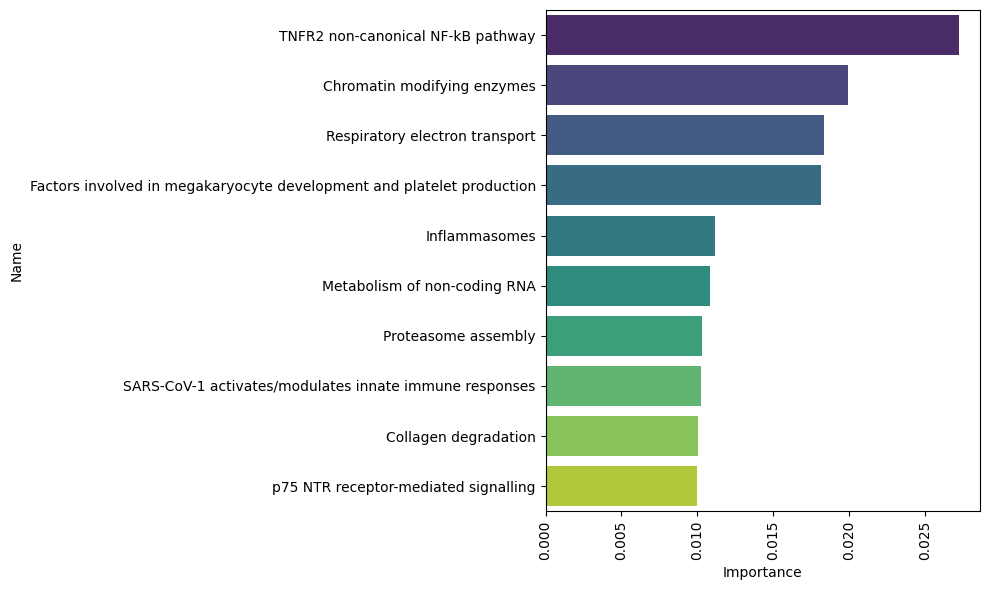

In [18]:
# Map pathway names by position (since columns are integers)
all_data_sv_pathway_importance['Name'] = mo_paths['Pathway_name'].iloc[all_data_sv_pathway_importance.index].values

plt.figure(figsize=(10, 6))
sns.barplot(
    data=all_data_sv_pathway_importance.sort_values(by='Importance', ascending=False).iloc[:10, :],
    x='Importance',
    y='Name',
    palette='viridis'
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [25]:
# save feature importances to feather
all_data_sv_pathway_importance.to_feather(project_root / '00_data' / 'feature_importances' / 'hierarchical_feature_importances_scRNA_removed.feather')
